# Brain Tumor Classification Using CNN

## Overview

In this project, we build a CNN to classify MRI brain scans into 4 categories:

- **glioma** — a type of tumor
- **meningioma** — a type of tumor
- **pituitary** — a type of tumor
- **notumor** — no tumor present

Both training and testing use the same 4-class folder structure from the Kaggle Brain Tumor MRI Dataset.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Preprocessing

- **Resizing:** All images resized to 150x150 pixels.
- **Normalization:** Pixel values scaled to [0, 1].
- **Data Augmentation:** Rotations, shifts, zooms, and flips applied during training.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# No augmentation for validation/test — just rescale
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/ml/Training',
    target_size=(150, 150),
    batch_size=32,
    class_mode='sparse'
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/ml/Testing',
    target_size=(150, 150),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

print('Classes:', train_generator.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## Model Architecture

A CNN with three convolutional blocks, a dense hidden layer with dropout, and a 4-neuron softmax output for multi-class classification.

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')  # 4 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # for integer labels
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Training

We train for 20 epochs with early stopping to avoid overfitting.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    epochs=20,
    validation_data=test_generator,
    validation_steps=test_generator.samples // 32,
    callbacks=callbacks
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1805s 10s/step - accuracy: 0.4739 - loss: 1.1103 - val_accuracy: 0.4263 - val_loss: 1.7767 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 61s 349ms/step - accuracy: 0.6082 - loss: 0.9157 - val_accuracy: 0.4281 - val_loss: 2.2219 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 61s 347ms/step - accuracy: 0.6582 - loss: 0.8326 - val_accuracy: 0.5356 - val_loss: 1.7737 - learning_rate: 0.0010
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 61s 347ms/step - accuracy: 0.6850 - loss: 0.7756 - val_accuracy: 0.5000 - val_loss: 2.3453 - learning_rate: 0.0010
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 62s 354ms/step - accuracy: 0.7118 - loss: 0.7271 - val_accuracy: 0.4575 - val_loss: 2.2313 - learning_rate: 0.0010
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 61s 347ms/step - accuracy: 0.7436 - loss: 0.6578 - val_accuracy: 0.6250 - val_loss: 1.4908 - learning_rate: 5.0000e-04
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 60s 343ms/step - accuracy:

## Training Curves

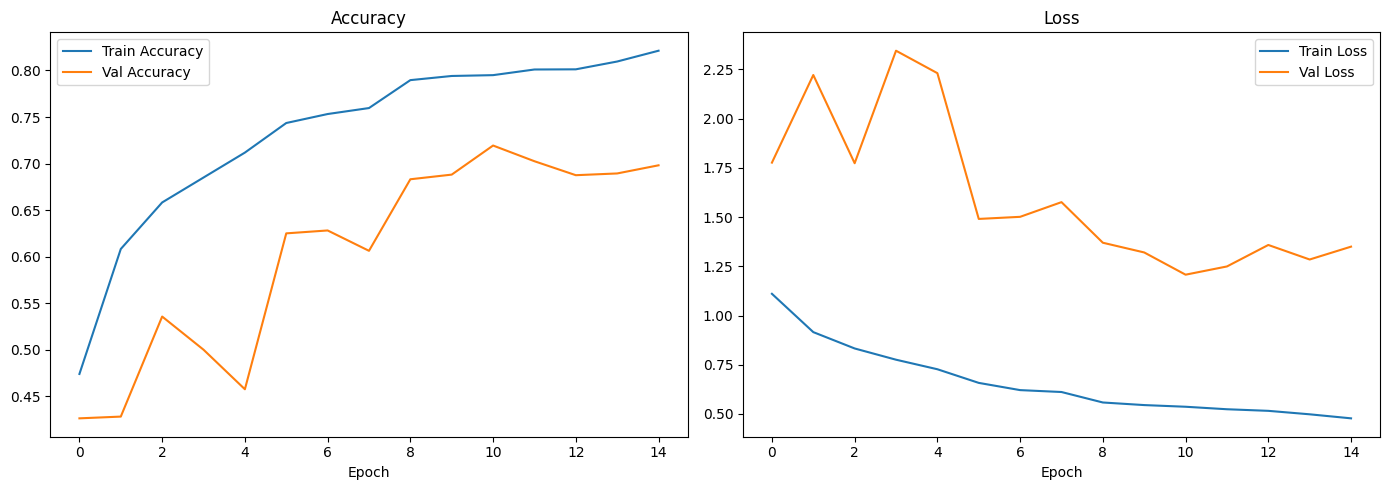

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## Testing and Evaluation

We evaluate on the held-out test set and display a classification report and confusion matrix.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions
test_generator.reset()
predictions = model.predict(test_generator, steps=len(test_generator))
predicted_labels = np.argmax(predictions, axis=1)
true_labels = test_generator.classes

class_names = list(test_generator.class_indices.keys())

accuracy = np.mean(predicted_labels == true_labels)
print(f'Test Accuracy: {accuracy * 100:.2f}%\n')
print(classification_report(true_labels, predicted_labels, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step
Test Accuracy: 71.94%

              precision    recall  f1-score   support

      glioma       0.84      0.46      0.60       400
  meningioma       0.63      0.45      0.52       400
     notumor       0.65      1.00      0.79       400
   pituitary       0.80      0.97      0.87       400

    accuracy                           0.72      1600
   macro avg       0.73      0.72      0.70      1600
weighted avg       0.73      0.72      0.70      1600



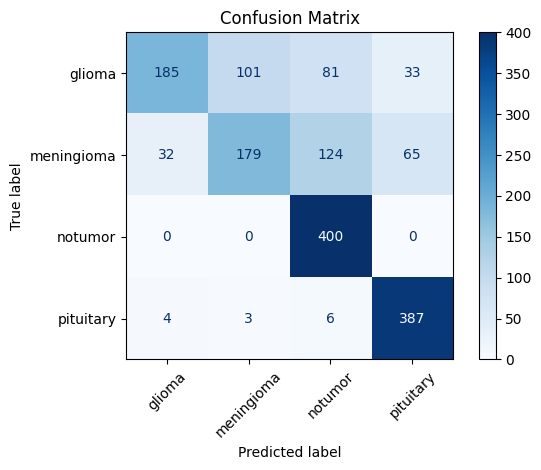

In [ ]:
# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Sample Predictions

Display a few test images alongside their true and predicted labels.

NameError: name 'os' is not defined

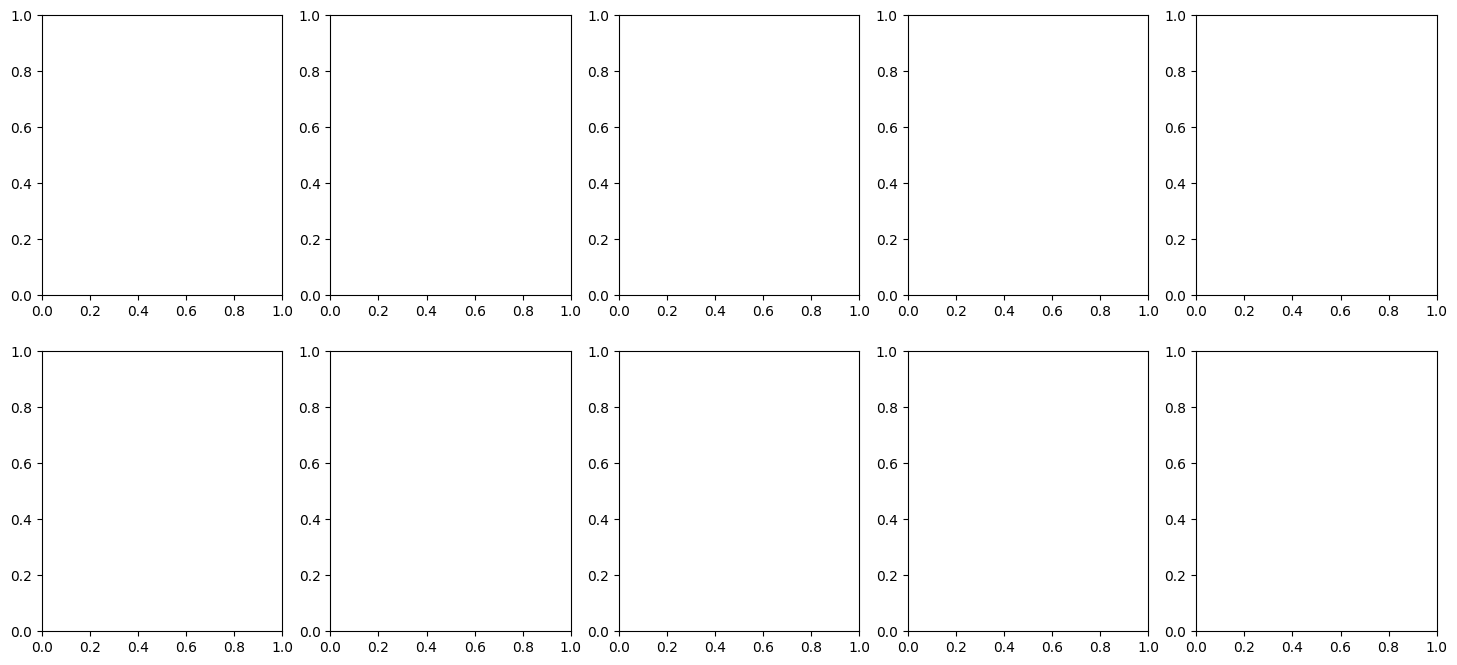

In [ ]:
from tensorflow.keras.preprocessing import image

test_dir = '/content/drive/MyDrive/ml/Testing'
class_names = list(test_generator.class_indices.keys())

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

sample_paths = []
sample_true = []
for cls_name, cls_idx in test_generator.class_indices.items():
    folder = os.path.join(test_dir, cls_name)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('jpg','jpeg','png'))]
    for f in files[:3]:
        sample_paths.append(os.path.join(folder, f))
        sample_true.append(cls_idx)

import os
for i, (img_path, true_idx) in enumerate(zip(sample_paths[:10], sample_true[:10])):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    pred = model.predict(np.expand_dims(img_array, axis=0), verbose=0)
    pred_idx = np.argmax(pred)
    color = 'green' if pred_idx == true_idx else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f'True: {class_names[true_idx]}\nPred: {class_names[pred_idx]}', color=color)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (green = correct, red = wrong)', fontsize=13)
plt.tight_layout()
plt.show()

## Summary

- **Model:** 3-block CNN with softmax output for 4-class classification
- **Training data:** `ml/Training/` (glioma, meningioma, notumor, pituitary)
- **Test data:** `ml/Testing/` (same 4 classes)
- **Loss function:** `sparse_categorical_crossentropy`
- **Future improvements:** Transfer learning (e.g. ResNet50, EfficientNet), larger input size, class weighting for imbalanced data